## Time Series Modeling for Stock Prices
This notebook demonstrates an example workflow for a model that learns to predict stock prices.
1. Load data
2. Initial data overview
3. Data preparation
4. Input feature construction
5. Network training
6. Evaluation of results

### Loading Tools

In [1]:
# packages used in the example
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.figsize"] = (14, 7)
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"


2026-05-09 20:06:07.917868: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Market Volatility and External Events Impact - WIG20 Example During the Pandemic

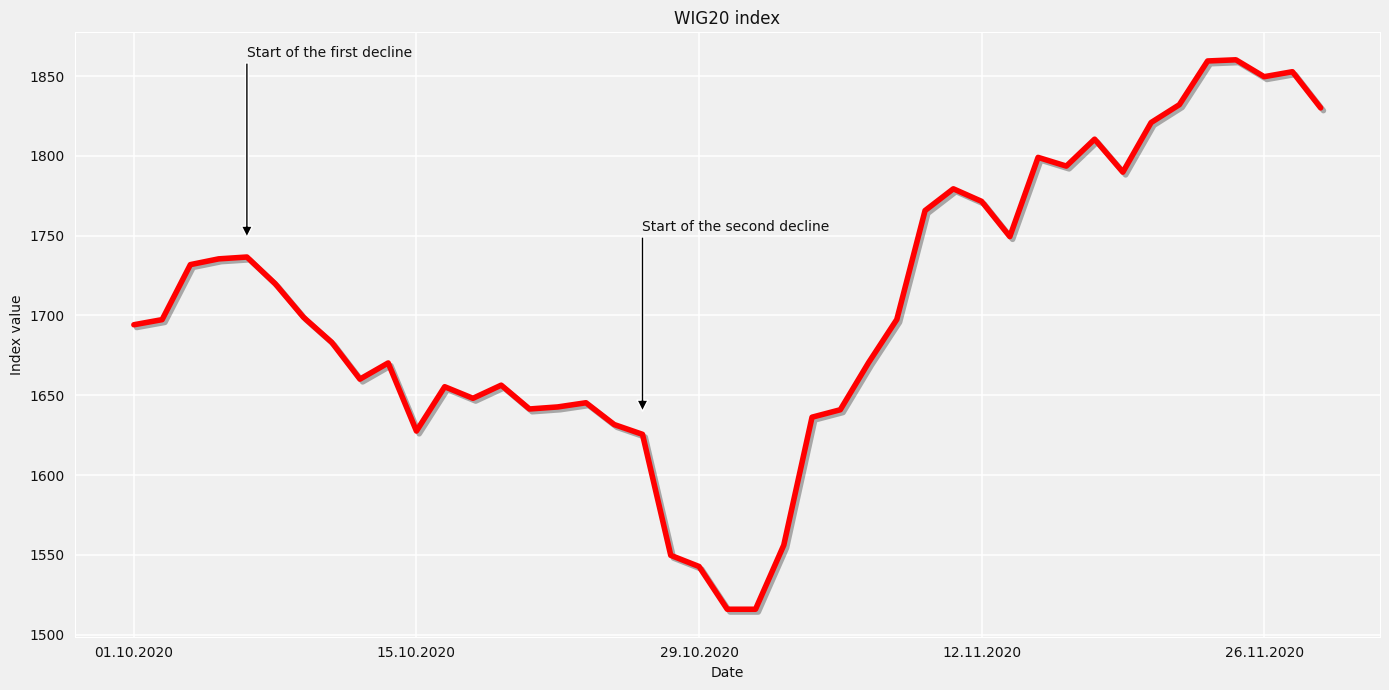

In [2]:
import matplotlib.patheffects as path_effects

dates_wig20 = [
    "01.10.2020",
    "02.10.2020",
    "05.10.2020",
    "06.10.2020",
    "07.10.2020",
    "08.10.2020",
    "09.10.2020",
    "12.10.2020",
    "13.10.2020",
    "14.10.2020",
    "15.10.2020",
    "16.10.2020",
    "19.10.2020",
    "20.10.2020",
    "21.10.2020",
    "22.10.2020",
    "23.10.2020",
    "26.10.2020",
    "27.10.2020",
    "28.10.2020",
    "29.10.2020",
    "30.10.2020",
    "01.11.2020",
    "02.11.2020",
    "03.11.2020",
    "04.11.2020",
    "05.11.2020",
    "06.11.2020",
    "09.11.2020",
    "10.11.2020",
    "12.11.2020",
    "13.11.2020",
    "16.11.2020",
    "17.11.2020",
    "18.11.2020",
    "19.11.2020",
    "20.11.2020",
    "23.11.2020",
    "24.11.2020",
    "25.11.2020",
    "26.11.2020",
    "27.11.2020",
    "30.11.2020",
]

wig20_values = [
    1694.18,
    1697.39,
    1731.85,
    1735.45,
    1736.61,
    1719.91,
    1698.91,
    1683.21,
    1660.12,
    1670.26,
    1627.59,
    1655.36,
    1648.11,
    1656.34,
    1641.42,
    1642.7,
    1645.32,
    1631.66,
    1625.54,
    1549.74,
    1542.76,
    1515.97,
    1515.97,
    1556.14,
    1636.28,
    1640.94,
    1670.43,
    1697.49,
    1765.71,
    1779.34,
    1771.49,
    1749.41,
    1799.02,
    1793.56,
    1810.43,
    1789.79,
    1820.85,
    1832.04,
    1859.42,
    1860.15,
    1849.57,
    1852.69,
    1830.04,
]

wig20_frame = pd.DataFrame({"WIG20": wig20_values}, index=dates_wig20)

chart, axis = plt.subplots(figsize=(14, 7))
axis.set_facecolor("#f0f0f0")
chart.patch.set_facecolor("#f0f0f0")

axis.grid(True, color="white", linewidth=1.2, alpha=0.9)
axis.tick_params(colors="#111111")
axis.xaxis.label.set_color("#111111")
axis.yaxis.label.set_color("#111111")
axis.title.set_color("#111111")

wig20_series = wig20_frame["WIG20"]
wig20_series.plot(
    ax=axis,
    style="r-",
    linewidth=4,
    path_effects=[path_effects.SimpleLineShadow(), path_effects.Normal()],
)

# 07.10.2020 - decision on yellow zone across the country + masks also required outdoors
# 27.10.2020 - entire country in red zone + significant changes to school operations

axis.set_title("WIG20 index")
axis.annotate(
    "Start of the first decline",
    color="#111111",
    xy=(4, 1719 + 30),
    xytext=(4, 1719 + 150),
    arrowprops=dict(facecolor="black", headwidth=8, width=2, headlength=8),
    horizontalalignment="left",
    verticalalignment="top",
)

axis.annotate(
    "Start of the second decline",
    color="#111111",
    xy=(18, 1610 + 30),
    xytext=(18, 1610 + 150),
    arrowprops=dict(facecolor="black", headwidth=8, width=2, headlength=8),
    horizontalalignment="left",
    verticalalignment="top",
)

axis.set_xlabel("Date")
axis.set_ylabel("Index value")

plt.tight_layout()
plt.show()


### Loading the Data File

In [3]:
stock_frame = pd.read_csv("../../data/google.csv")

### Dataset Overview

In [4]:
stock_frame.describe()

,High,Low,Open,Close,Volume,Adj Close
count,4317.000000,4317.000000,4317.000000,4317.000000,4.317000e+03,4317.000000
mean,639.682936,627.615621,633.603748,633.852357,6.523837e+06,633.852357
std,561.783142,552.069438,556.527532,557.255541,7.830526e+06,557.255541
min,50.680038,47.800831,49.409801,49.818268,7.922000e+03,49.818268
25%,247.507278,241.469910,244.832306,244.334183,1.593563e+06,244.334183
50%,401.988251,395.168823,399.004425,398.561096,3.851583e+06,398.561096
75%,933.440002,923.030029,929.059998,928.799988,8.268878e+06,928.799988
max,2936.409912,2912.290039,2918.989990,2916.840088,8.254163e+07,2916.840088


In [5]:
stock_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4317 entries, 0 to 4316
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4317 non-null   object 
 1   High       4317 non-null   float64
 2   Low        4317 non-null   float64
 3   Open       4317 non-null   float64
 4   Close      4317 non-null   float64
 5   Volume     4317 non-null   float64
 6   Adj Close  4317 non-null   float64
dtypes: float64(6), object(1)
memory usage: 236.2+ KB


In [6]:
stock_frame.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2004-08-19,51.835709,47.800831,49.813290,49.982655,44871361.0,49.982655
1,2004-08-20,54.336334,50.062355,50.316402,53.952770,22942874.0,53.952770
2,2004-08-23,56.528118,54.321388,55.168217,54.495735,18342897.0,54.495735
3,2004-08-24,55.591629,51.591621,55.412300,52.239197,15319808.0,52.239197
4,2004-08-25,53.798351,51.746044,52.284027,52.802086,9232276.0,52.802086


## Preparing Input Features

In [7]:
# scale closing values to range 0-1
close_values = stock_frame.iloc[:, 3:4].values
value_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close_values = value_scaler.fit_transform(close_values)
scaled_close_values


array([[1.40608776e-04],
       [3.15935047e-04],
       [2.00670999e-03],
       ...,
       [9.50609507e-01],
       [9.57878900e-01],
       [9.57140076e-01]])

### Splitting Training and Test Samples

In [8]:
train_sequences = []
train_targets = []
lookback_window = 70  # observation window length

for row_idx in range(lookback_window, 3500):
    train_sequences.append(scaled_close_values[row_idx - lookback_window : row_idx, 0])
    train_targets.append(scaled_close_values[row_idx, 0])

train_sequences = np.array(train_sequences)
train_targets = np.array(train_targets)

test_sequences = []
test_targets = []

for row_idx in range(3501, 4300):
    test_sequences.append(scaled_close_values[row_idx - lookback_window : row_idx, 0])
    test_targets.append(scaled_close_values[row_idx, 0])

test_sequences = np.array(test_sequences)
test_targets = np.array(test_targets)


In [9]:
train_sequences = np.reshape(
    train_sequences,
    (train_sequences.shape[0], train_sequences.shape[1], 1),
)
test_sequences = np.reshape(
    test_sequences,
    (test_sequences.shape[0], test_sequences.shape[1], 1),
)


### Building the LSTM Network

In [10]:
# build LSTM network to predict the next value in the series
price_forecaster = Sequential()
price_forecaster.add(LSTM(units=50, return_sequences=True))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(LSTM(units=50, return_sequences=True))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(LSTM(units=50, return_sequences=True))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(LSTM(units=50))
price_forecaster.add(Dropout(0.2))
price_forecaster.add(Dense(units=1))
price_forecaster.compile(optimizer="adam", loss="mean_squared_error")


### Model Training

In [11]:
price_forecaster.fit(train_sequences, train_targets, epochs=10, batch_size=32)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 0.0018
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 3.1858e-04
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 2.7475e-04
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 2.7923e-04
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 2.4121e-04
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 2.2041e-04
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 2.1252e-04
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 2.0956e-04
Epoch 9/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 2.1538e-04
Epoch 10/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 1.7326e-04


### Generating Predictions for the Test Set

In [12]:
forecast_scaled = price_forecaster.predict(test_sequences)
forecast_values = value_scaler.inverse_transform(forecast_scaled)
forecast_values


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


array([[1146.5002],
       [1147.8691],
       [1150.1337],
       [1153.2162],
       [1156.9645],
       [1161.1628],
       [1165.8904],
       [1171.199 ],
       [1177.1208],
       [1183.701 ],
       [1190.7643],
       [1198.0065],
       [1205.1298],
       [1211.7958],
       [1217.8043],
       [1223.0405],
       [1227.5061],
       [1231.278 ],
       [1234.4987],
       [1237.2921],
       [1239.7335],
       [1241.8623],
       [1243.6765],
       [1245.1487],
       [1246.1688],
       [1246.6434],
       [1246.5371],
       [1245.8396],
       [1244.6072],
       [1242.9448],
       [1241.0503],
       [1239.1858],
       [1237.5767],
       [1236.408 ],
       [1235.7609],
       [1235.5225],
       [1235.4692],
       [1235.343 ],
       [1234.8252],
       [1233.7075],
       [1231.8593],
       [1229.2876],
       [1226.0857],
       [1222.4324],
       [1218.5029],
       [1214.4114],
       [1210.2758],
       [1206.2639],
       [1202.5845],
       [1199.2877],


In [13]:
# observed values, used for comparison with the forecast
observed_values = value_scaler.inverse_transform(test_targets.reshape(-1, 1))
observed_values


array([[1172.2199707 ],
       [1196.56005859],
       [1191.        ],
       [1186.95996094],
       [1181.01000977],
       [1262.58996582],
       [1239.13000488],
       [1251.        ],
       [1271.        ],
       [1228.01000977],
       [1220.01000977],
       [1228.        ],
       [1205.90002441],
       [1229.61999512],
       [1225.        ],
       [1237.        ],
       [1240.4699707 ],
       [1249.90002441],
       [1243.        ],
       [1236.97998047],
       [1235.18994141],
       [1229.26000977],
       [1224.72998047],
       [1202.0300293 ],
       [1205.02001953],
       [1208.        ],
       [1200.        ],
       [1207.14001465],
       [1208.81994629],
       [1227.59997559],
       [1241.29003906],
       [1237.44995117],
       [1244.22998047],
       [1234.97998047],
       [1204.27001953],
       [1193.80004883],
       [1186.30004883],
       [1158.67004395],
       [1172.18994141],
       [1161.63000488],
       [1172.7199707 ],
       [1170.739

### Comparison of Actual and Predicted Values

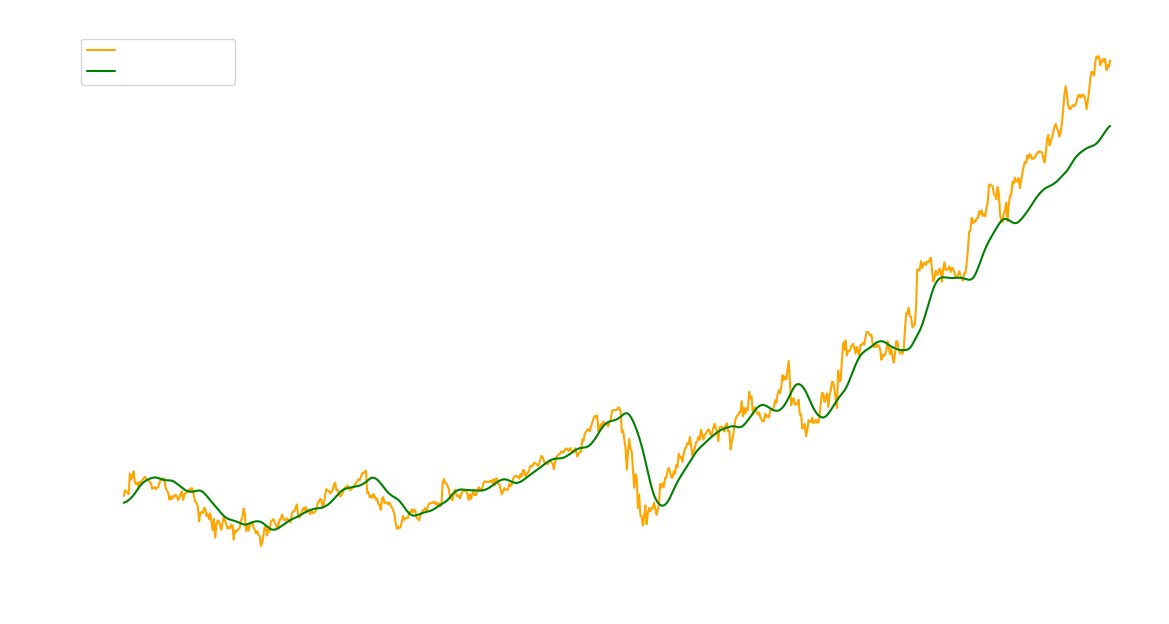

In [14]:
plt.plot(observed_values, color="orange", label="observed price")
plt.plot(forecast_values, color="green", label="forecast price")
plt.title("Google stock price forecast")
plt.xlabel("time")
plt.ylabel("stock price")
plt.legend()
plt.show()


### Evaluation of Results

In [15]:
# basic model quality metrics
print(f'RMSE {metrics.root_mean_squared_error(forecast_values, observed_values)}')
print(f'MAE {metrics.mean_absolute_error(forecast_values, observed_values)}')


RMSE 101.4801164336929
MAE 69.83561001850458
